In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

In [23]:
df=pd.read_csv(r"C:\Users\Asus\.vscode\heart_disease\dataset_heart.csv")

In [24]:
df.head()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [25]:
df.tail()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,1
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,1
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,1
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,1
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels                 

In [27]:
df.describe()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [28]:
df.shape

(270, 14)

In [29]:
df.isnull().sum()

age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
#checking for out of range data
#check if age is out of range
df=df[(df['age'] > 0) & (df['age'] < 100)]

In [32]:
#feature engineering
bins=[0, 40, 55, 70, 100]
labels=['young','middle-aged','senior','elderly']
df['age_group']=pd.cut(df['age'],bins=bins,labels=labels)

In [33]:
df['high_blood_pressure'] = (df['resting blood pressure'] > 130).astype(int)

In [34]:
df['high_cholestoral'] = (df['serum cholestoral'] > 240).astype(int)  # 240+ = high risk

In [35]:
df['oldpeak_level'] = pd.cut(df['oldpeak'], bins=[-1, 1, 2, df['oldpeak'].max()],
                             labels=['low', 'moderate', 'high'])

In [36]:
#Difference between max predicted heart rate (220 - age) and max heart rate
def add_hr_deficit(X):
    X = X.copy()
    X['hr_deficit'] = (220 - X['age']) - X['max heart rate']
    return X

In [37]:
df

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease,age_group,high_blood_pressure,high_cholestoral,oldpeak_level
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2,senior,0,1,high
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1,senior,0,1,moderate
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2,senior,0,1,low
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1,senior,0,1,low
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1,elderly,0,1,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,1,middle-aged,1,0,low
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,1,middle-aged,0,1,low
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,1,senior,1,1,moderate
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,1,senior,1,0,low


In [38]:
df.to_csv('cleaned_dataset_heart.csv', index=False)

In [39]:
target = 'heart_disease'
x = df.drop(columns=['heart disease'])
y = df['heart disease']

In [40]:
# Split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
#pipeline
# Apply feature engineering
feature_pipe = Pipeline([
    ('hr_deficit', FunctionTransformer(add_hr_deficit))
])
df_transformed = feature_pipe.fit_transform(df)
# Identify numerical columns
numeric_features = x.select_dtypes(include='number').columns
# Preprocessing: scale numeric features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features)
])
# Final pipeline: preprocessing + logistic regression
model_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)
# Train the model
model_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [42]:
# Predict and evaluate
y_pred = model_pipeline.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.91      0.91      0.91        33
           2       0.86      0.86      0.86        21

    accuracy                           0.89        54
   macro avg       0.88      0.88      0.88        54
weighted avg       0.89      0.89      0.89        54

[[30  3]
 [ 3 18]]


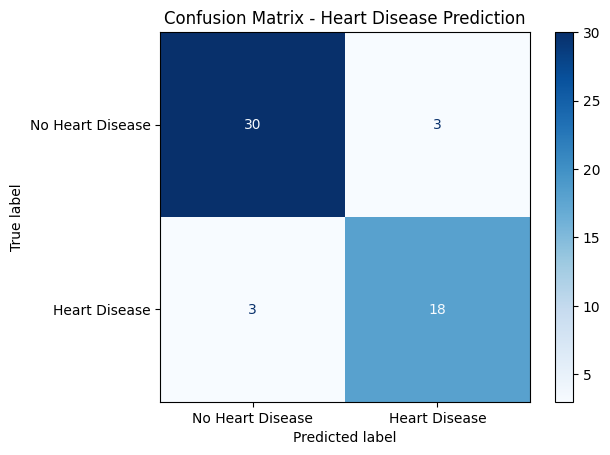

In [43]:
# Predict using your trained model (logreg_pipeline)
y_pred = model_pipeline.predict(x_test)
# Plot confusion matrix with custom labels
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Heart Disease Prediction")
plt.show()

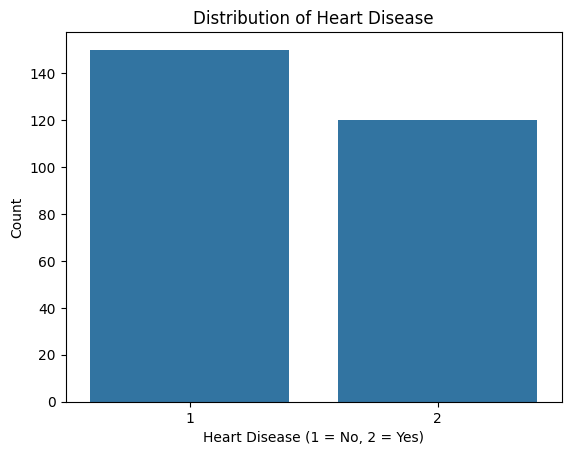

In [44]:
sns.countplot(x='heart disease', data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (1 = No, 2 = Yes)")
plt.ylabel("Count")
plt.show()

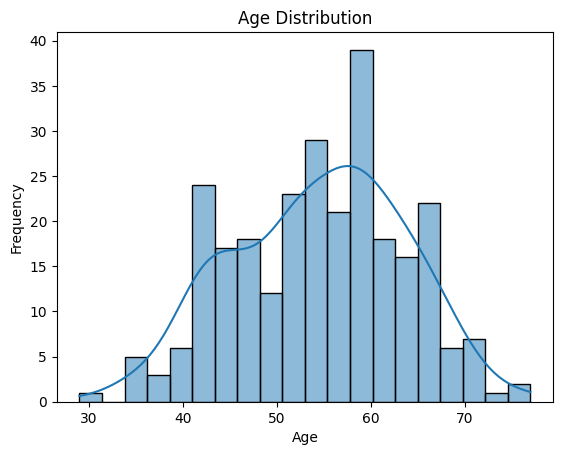

In [45]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

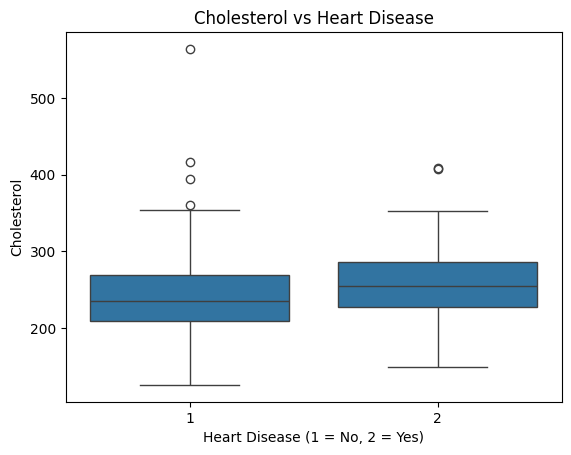

In [46]:
sns.boxplot(x='heart disease', y='serum cholestoral', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease (1 = No, 2 = Yes)")
plt.ylabel("Cholesterol")
plt.show()

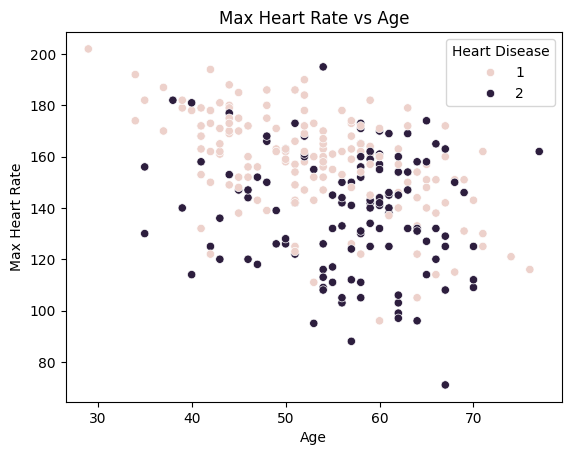

In [47]:
sns.scatterplot(x='age', y='max heart rate', hue='heart disease', data=df)
plt.title("Max Heart Rate vs Age")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(title='Heart Disease')
plt.show()

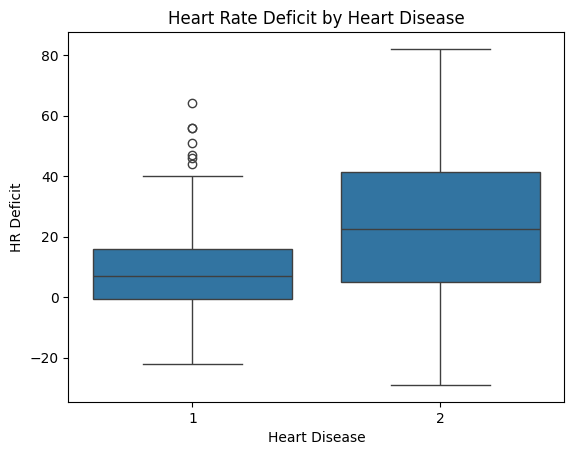

In [48]:
sns.boxplot(x='heart disease', y='hr_deficit', data=df_transformed)
plt.title("Heart Rate Deficit by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("HR Deficit")
plt.show()


In [49]:
joblib.dump(model_pipeline, 'heart_disease_model.pkl')

['heart_disease_model.pkl']